# Atari Return Prediction: Adam vs UPGD Sweep Analysis

## Data Issues (2026-03-18)

### Adam sweep (20 expected configs: 10 LR x 2 reinit)

- **reinit=False**: 10 runs downloaded, **9 completed** (1 stopped at step 1,988,000). All 9 have full loss data.
- **reinit=True**: 12 runs downloaded, **0 completed**. Max step reached is 2,496,000 (target: 2,600,000). Close to done but `load_experiment_data` drops them.

### UPGD sweep (600 expected configs: 5 LR x 4 beta x 5 sigma x 3 wd x 2 reinit)

- **reinit=False**: 337 runs downloaded, **263 completed**.
- **reinit=True**: 485 runs downloaded, **0 completed**. Max step is only 1,104,000 (~42%). Still running.

### UPGD loss divergence

Of the 263 completed UPGD no-reinit runs, only **60 have any `loss` data**. The other 203 log `baseline_loss` and `target_magnitude` at all steps, but `loss` is completely absent from Comet (confirmed via API: `min=null, max=null`). The model's forward pass is producing NaN at higher learning rates, and Comet silently drops NaN values.

The pattern is entirely explained by learning rate:

| LR | Completed runs | Have loss data |
|----|---------------|----------------|
| 2^-15 | 60 | **60** (100%) |
| 2^-12 | 60 | 0 |
| 2^-9 | 60 | 0 |
| 2^-6 | 57 | 0 |
| 2^-3 | 26 | 0 |

Only LR=2^-15 avoids divergence. Within those 60 runs there is full coverage of beta_utility (4) x sigma (5) x weight_decay (3), so sensitivity analysis for those 3 hyperparams is still possible.

### Implications for this notebook

- **No reinit=True vs False comparison is possible yet** (for either optimizer).
- UPGD LR sensitivity has only 1 non-divergent value — effectively no LR sweep.
- All plots below use **no-reinit runs only**, with 1 seed per config (seeds are batched inside each run).

In [1]:
# Data collection command:
# `python -m phd.research_utils.scripts.comet_download --project=atari-prediction --n_threads=8 --output_dir=data/`

In [2]:
from collections import defaultdict
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from phd.research_utils.analysis.analysis_utils import *
from phd.research_utils.analysis.plotting import plot_learning_curves, plot_param_sensitivity

sns.set_theme('notebook', 'white')
%matplotlib inline

In [ ]:
save_path = 'figures/'
config_data_path = 'data/atari-prediction_params.csv'
run_data_path = 'data/atari-prediction_metrics.csv'

# The metrics CSV uses 'update_step' instead of 'step'. Rename before loading.
run_df_raw = pd.read_csv(run_data_path, index_col=0)
if 'update_step' in run_df_raw.columns:
    run_df_raw = run_df_raw.rename(columns={'update_step': 'step'})
    run_df_raw.to_csv(run_data_path)

config_dfs, run_dfs = load_experiment_data(config_data_path, run_data_path)

# Show sweep names and run counts
{k: len(v) for k, v in config_dfs.items()}

## Data Exploration

Check for data quality issues before plotting.

In [ ]:
# Focus on v2 sweeps only
target_sweeps = ['adam_sweep_v2', 'upgd_sweep_v2']
config_dfs = {k: v for k, v in config_dfs.items() if k in target_sweeps}
run_dfs = {k: v for k, v in run_dfs.items() if k in target_sweeps}

for name in target_sweeps:
    cfg = config_dfs[name]
    runs = run_dfs[name]
    print(f"\n=== {name} ===")
    print(f"  Configs (completed runs): {len(cfg)}")
    print(f"  Metric rows: {len(runs)}")
    print(f"  Unique run_ids in metrics: {runs['run_id'].nunique()}")
    print(f"  Step range: {runs['step'].min()} - {runs['step'].max()}")
    print(f"  Inferred sweep vars: {infer_sweep_vars(cfg)}")
    print(f"  reinit values: {cfg['train|reinit_at_game_boundary'].value_counts().to_dict()}")

In [5]:
# Check for NaN in the loss column
for name in target_sweeps:
    runs = run_dfs[name]
    n_total = len(runs)
    n_loss_nan = runs['loss'].isna().sum()
    n_baseline_nan = runs['baseline_loss'].isna().sum()
    print(f"{name}: {n_loss_nan}/{n_total} loss NaN, {n_baseline_nan}/{n_total} baseline_loss NaN")

    # Drop rows where loss is NaN (summary-only rows)
    if n_loss_nan > 0:
        run_dfs[name] = runs[runs['loss'].notna()].copy()
        print(f"  -> Dropped {n_loss_nan} NaN loss rows, {len(run_dfs[name])} remaining")

adam_sweep_v2: 0/5850 loss NaN, 0/5850 baseline_loss NaN
upgd_sweep_v2: 153337/170950 loss NaN, 0/170950 baseline_loss NaN
  -> Dropped 153337 NaN loss rows, 17613 remaining


## Find Best Hyperparameters

Split by `train|reinit_at_game_boundary` to find separate best configs for reinit=True vs reinit=False.

In [6]:
sweep_split_vars = {
    'adam_sweep_v2': ['train|reinit_at_game_boundary'],
    'upgd_sweep_v2': ['train|reinit_at_game_boundary'],
}

best_config_dfs, best_run_dfs, best_hyperparam_vals = get_best_ablation_values(
    config_dfs, run_dfs,
    sweep_split_vars=sweep_split_vars,
    split_dfs_by_split_vars=True,
    metric_col='loss',
    metric_direction='min',
    metric_type='final_avg',
    step_col='step',
)

print("\n=== Keys ===")
print(list(best_hyperparam_vals.keys()))
for k, v in best_hyperparam_vals.items():
    print(f"\n{k}: {v}")
    print(f"  Runs: {len(best_config_dfs[k])}")


=== upgd_sweep_v2 ===

Configuration: train|reinit_at_game_boundary=False | # runs: 1
  Best optimizer|beta_utility=0.999
  Best optimizer|learning_rate=2**-15
  Best optimizer|sigma=0.001
  Best optimizer|weight_decay=0.01


=== adam_sweep_v2 ===

Configuration: train|reinit_at_game_boundary=False | # runs: 1
  Best optimizer|learning_rate=2**-15


=== Keys ===
['upgd_sweep_v2&train|reinit_at_game_boundary=False', 'adam_sweep_v2&train|reinit_at_game_boundary=False']

upgd_sweep_v2&train|reinit_at_game_boundary=False: {'optimizer|beta_utility': 0.999, 'optimizer|learning_rate': 3.0517578125e-05, 'optimizer|sigma': 0.001, 'optimizer|weight_decay': 0.01}
  Runs: 1

adam_sweep_v2&train|reinit_at_game_boundary=False: {'optimizer|learning_rate': 3.0517578125e-05}
  Runs: 1


## 1. Main Comparison: Adam vs UPGD, Reinit vs No-Reinit

Learning curves for the best hyperparameter configuration of each condition.

In [7]:
# Combine all best runs into a single dataframe with a label column
algo_map = {}
for k in best_hyperparam_vals.keys():
    # Parse sweep name and reinit value from key like 'adam_sweep_v2&train|reinit_at_game_boundary=True'
    parts = k.split('&')
    sweep = parts[0].replace('_sweep_v2', '').upper()
    reinit_val = 'Reinit' if 'True' in parts[1] else 'No Reinit'
    algo_map[k] = f'{sweep} ({reinit_val})'

print("Algorithm map:", algo_map)

combined_config_df = pd.concat(
    [df.assign(split_name=k) for k, df in best_config_dfs.items()]
)
combined_run_df = pd.concat(list(best_run_dfs.values()))

combined_config_df = combined_config_df[combined_config_df['split_name'].isin(algo_map.keys())].copy()
valid_run_ids = combined_config_df['run_id'].unique()
combined_run_df = combined_run_df[combined_run_df['run_id'].isin(valid_run_ids)].copy()
combined_config_df['algo'] = combined_config_df['split_name'].map(algo_map)

print(f"\nTotal runs: {len(combined_config_df)}")
print(combined_config_df['algo'].value_counts())

Algorithm map: {'upgd_sweep_v2&train|reinit_at_game_boundary=False': 'UPGD (No Reinit)', 'adam_sweep_v2&train|reinit_at_game_boundary=False': 'ADAM (No Reinit)'}

Total runs: 2
algo
UPGD (No Reinit)    1
ADAM (No Reinit)    1
Name: count, dtype: int64


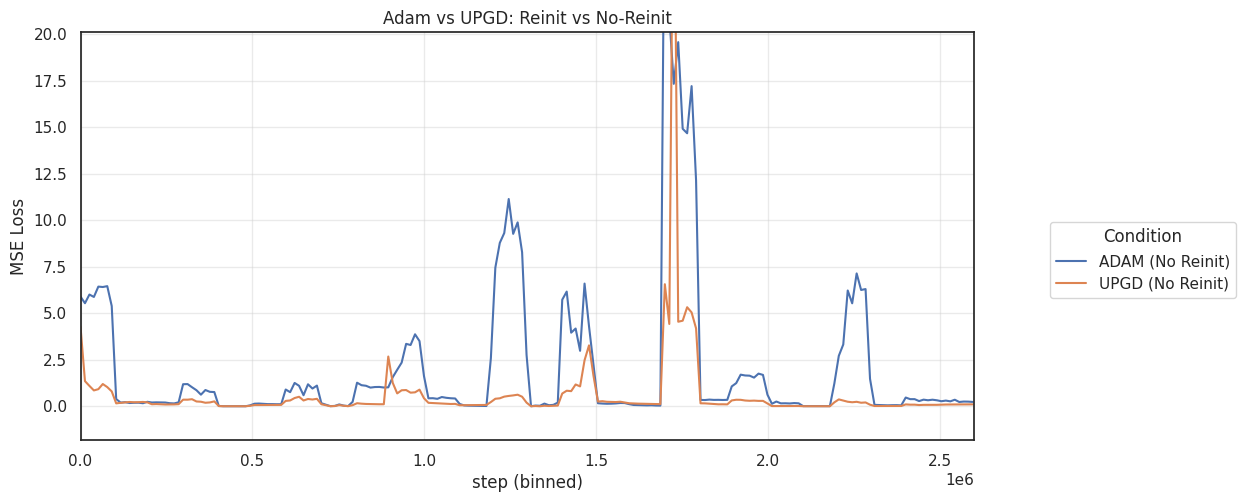

In [8]:
plot_learning_curves(
    run_df=combined_run_df,
    config_df=combined_config_df,
    n_bins=200,
    figsize=(10, 5),
    hue_col='algo',
    legend_title='Condition',
    show_ci=True,
)
plt.title('Adam vs UPGD: Reinit vs No-Reinit')
plt.ylabel('MSE Loss')
plt.show()

## 2. Learning Curves with Baseline Loss

Compare model loss against the running-mean baseline to contextualize prediction quality.

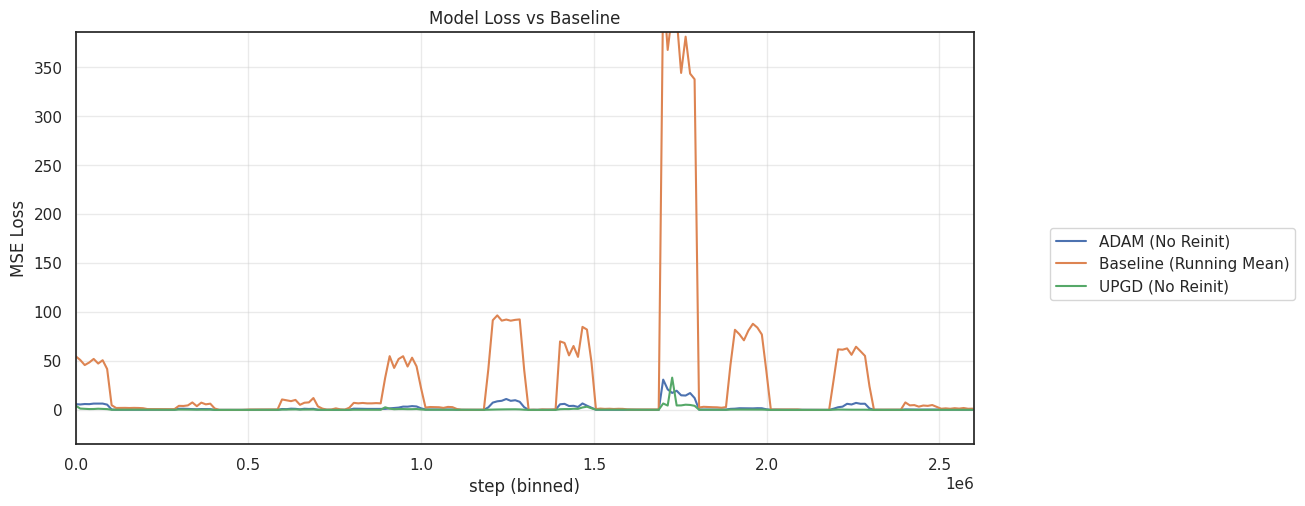

In [9]:
# Create a long-form dataframe with both loss and baseline_loss for the best runs
baseline_dfs = []
for k, run_df in best_run_dfs.items():
    cfg_df = best_config_dfs[k]
    # Get baseline loss from same runs
    baseline_rows = run_df[['run_id', 'step', 'baseline_loss']].copy()
    baseline_rows = baseline_rows.rename(columns={'baseline_loss': 'loss'})
    baseline_rows['algo'] = 'Baseline (Running Mean)'

    model_rows = run_df[['run_id', 'step', 'loss']].copy()
    model_rows['algo'] = algo_map[k]

    baseline_dfs.append(baseline_rows)
    baseline_dfs.append(model_rows)

baseline_combined = pd.concat(baseline_dfs, ignore_index=True)

# Use a single baseline (from any condition — they share the same data stream)
# Just pick one set of baseline rows to avoid duplicates
first_key = list(best_run_dfs.keys())[0]
single_baseline = best_run_dfs[first_key][['run_id', 'step', 'baseline_loss']].copy()
single_baseline = single_baseline.rename(columns={'baseline_loss': 'loss'})
single_baseline['algo'] = 'Baseline (Running Mean)'

model_dfs = []
for k, run_df in best_run_dfs.items():
    rows = run_df[['run_id', 'step', 'loss']].copy()
    rows['algo'] = algo_map[k]
    model_dfs.append(rows)

plot_df = pd.concat([single_baseline] + model_dfs, ignore_index=True)

plot_learning_curves(
    run_df=plot_df,
    n_bins=200,
    figsize=(10, 5),
    hue_col='algo',
    legend_title='',
    show_ci=False,
)
plt.title('Model Loss vs Baseline')
plt.ylabel('MSE Loss')
plt.show()

## 3. Adam Learning Rate Sensitivity

Sensitivity to learning rate, with reinit as hue.

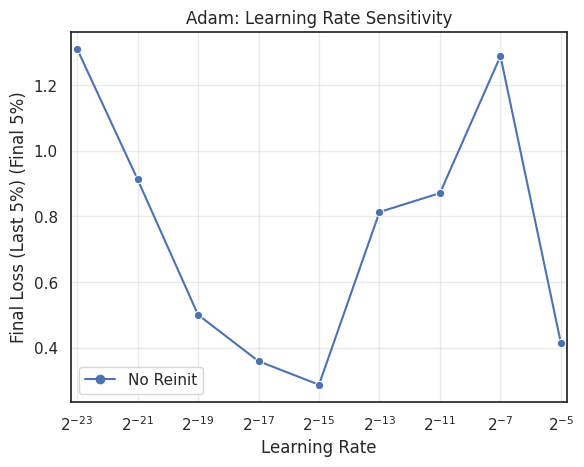

In [10]:
adam_config = config_dfs['adam_sweep_v2'].copy()
adam_run = run_dfs['adam_sweep_v2'].copy()

adam_config['Reinit'] = adam_config['train|reinit_at_game_boundary'].map({True: 'Reinit', False: 'No Reinit'})

plot_param_sensitivity(
    run_df=adam_run,
    config_df=adam_config,
    x_col='optimizer|learning_rate',
    title='Adam: Learning Rate Sensitivity',
    x_label='Learning Rate',
    y_label='Final Loss (Last 5%)',
    metric_col='loss',
    metric_type='final_avg',
    step_col='step',
    hue_col='Reinit',
    legend_title='',
    pow_2_x_axis=True,
    show_ci=True,
)
plt.show()

## 4. UPGD Hyperparameter Sensitivity

One plot per hyperparameter (learning_rate, beta_utility, sigma, weight_decay), with reinit as hue. For each plot, all other hyperparameters are held at their best values (separately for reinit and no-reinit).

In [11]:
# Get best hyperparams for each reinit condition
upgd_keys = [k for k in best_hyperparam_vals if k.startswith('upgd_sweep_v2')]
print("UPGD split keys:", upgd_keys)
for k in upgd_keys:
    print(f"  {k}: {best_hyperparam_vals[k]}")

# UPGD sensitivity: vary one param at a time, hold others at best, split by reinit
upgd_config = config_dfs['upgd_sweep_v2'].copy()
upgd_run = run_dfs['upgd_sweep_v2'].copy()
upgd_config['Reinit'] = upgd_config['train|reinit_at_game_boundary'].map({True: 'Reinit', False: 'No Reinit'})

# Get hyperparam names (should be same for both reinit conditions)
upgd_hyperparam_names = list(best_hyperparam_vals[upgd_keys[0]].keys())
print("\nHyperparams to plot:", upgd_hyperparam_names)

UPGD split keys: ['upgd_sweep_v2&train|reinit_at_game_boundary=False']
  upgd_sweep_v2&train|reinit_at_game_boundary=False: {'optimizer|beta_utility': 0.999, 'optimizer|learning_rate': 3.0517578125e-05, 'optimizer|sigma': 0.001, 'optimizer|weight_decay': 0.01}

Hyperparams to plot: ['optimizer|beta_utility', 'optimizer|learning_rate', 'optimizer|sigma', 'optimizer|weight_decay']


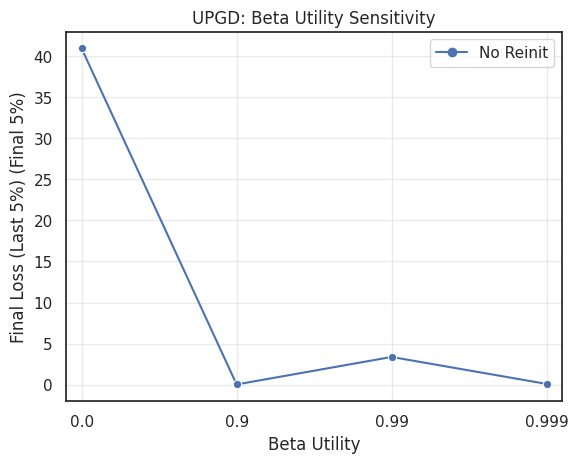

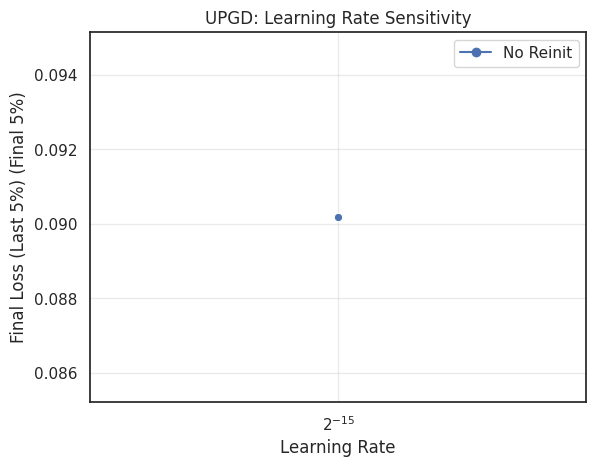

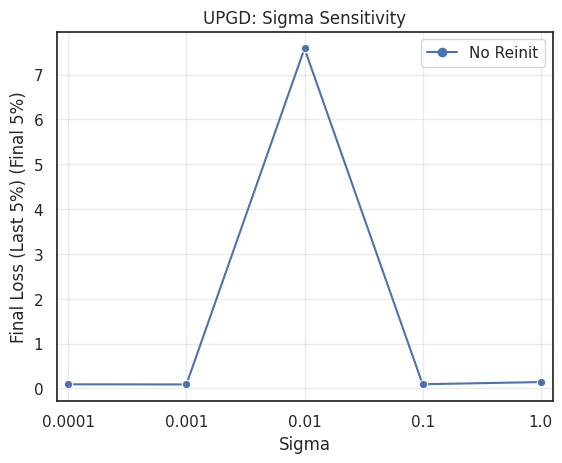

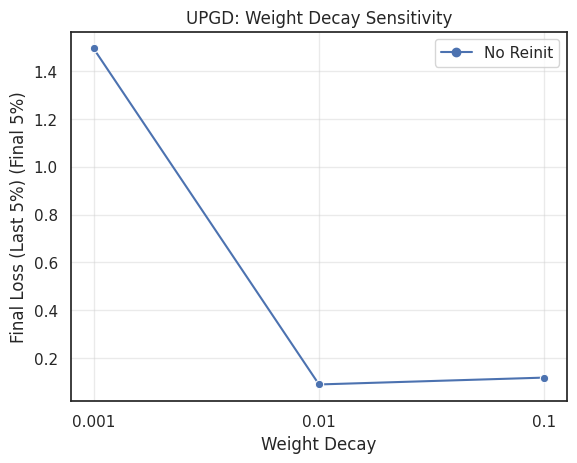

In [12]:
# For each hyperparam, hold others at their best values per reinit condition,
# then combine into one plot with reinit as hue.
for param_name in upgd_hyperparam_names:
    # For each reinit condition, select runs where all OTHER params are at best
    dfs_to_plot = []
    for upgd_key in upgd_keys:
        best_vals = best_hyperparam_vals[upgd_key]
        reinit_val = True if 'True' in upgd_key else False

        # Hold all params except the target at their best values
        hold_values = {k: v for k, v in best_vals.items() if k != param_name}
        hold_values['train|reinit_at_game_boundary'] = reinit_val

        sel_run, sel_config = select_experiment_runs(
            run_df=upgd_run,
            config_df=upgd_config,
            chosen_values=hold_values,
        )
        dfs_to_plot.append((sel_run, sel_config))

    plot_run = pd.concat([d[0] for d in dfs_to_plot], ignore_index=True)
    plot_config = pd.concat([d[1] for d in dfs_to_plot], ignore_index=True)

    param_label = param_name.split('|')[-1].replace('_', ' ').title()
    plot_param_sensitivity(
        run_df=plot_run,
        config_df=plot_config,
        x_col=param_name,
        title=f'UPGD: {param_label} Sensitivity',
        x_label=param_label,
        y_label='Final Loss (Last 5%)',
        metric_col='loss',
        metric_type='final_avg',
        step_col='step',
        hue_col='Reinit',
        legend_title='',
        pow_2_x_axis='learning_rate' in param_name,
        show_ci=True,
    )
    plt.show()